# Plot: Sensitivity to Vote Share (Model II)
Extracted from task2/scripts/T2main.py


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

PAPER_RC = {
    # Font sizes
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "figure.titlesize": 12,

    # Figure settings
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.figsize": (6.5, 3.5),

    # Style
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.axisbelow": True,

    # Font family
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
}

def apply_paper_style():
    """Apply paper-ready matplotlib style."""
    plt.rcParams.update(PAPER_RC)

apply_paper_style()


In [2]:
# =========================
# 1) 路径与配置
# =========================
# 默认从 notebooks/26Feb2-mcm 目录运行
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
DATA_DIR = os.path.join(BASE_DIR, "data", "26Feb2-mcm")
FIGDIR = os.path.join(BASE_DIR, "figures", "26Feb2-mcm")

# LaTeX single-column figure sizes
FIGSIZE_STANDARD = (6.5, 3.5)
FIGSIZE_WIDE = (6.5, 2.8)
FIGSIZE_TALL = (6.5, 4.5)
FIGSIZE_DUAL = (8.6, 3.2)
DPI = 300

FIGSIZE = FIGSIZE_STANDARD

N = 10
OUT_PDF = os.path.join(FIGDIR, "task2-math_sensitivity_vote_share_N10.pdf")

os.makedirs(FIGDIR, exist_ok=True)


In [3]:
# Paper style settings

def rank_share_from_values(values: np.ndarray) -> np.ndarray:
    """Compute rank-share from values."""
    s = pd.Series(values)
    r = s.rank(ascending=False, method="average").to_numpy(dtype=float)
    N = len(r)
    score = (N - r + 1.0)
    return score / score.sum()

def plot_sensitivity_curve(N: int = 10, output_path: str = "math_sensitivity_vote_share_N10.pdf"):
    """Generate sensitivity comparison plot."""
    vs = np.linspace(0.01, 0.80, 200)
    fv_pct = []
    fv_rank = []

    for v in vs:
        rest = (1.0 - v) / (N - 1)
        V = np.array([v] + [rest] * (N - 1), dtype=float)
        fv_pct.append(V[0])
        FV = rank_share_from_values(V)
        fv_rank.append(FV[0])

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(vs, fv_pct, label="Percentage: FV = vote share", linewidth=2, color="#4C78A8")
    ax.plot(vs, fv_rank, label="Rank: FV = rank-share", linewidth=2, color="#F58518")
    ax.set_xlabel("Target contestant vote share")
    ax.set_ylabel("FV assigned to target")
    fig.suptitle(f"Model II: Sensitivity to magnitude (N={N})", x=0.52, y=0.97, ha="center", fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


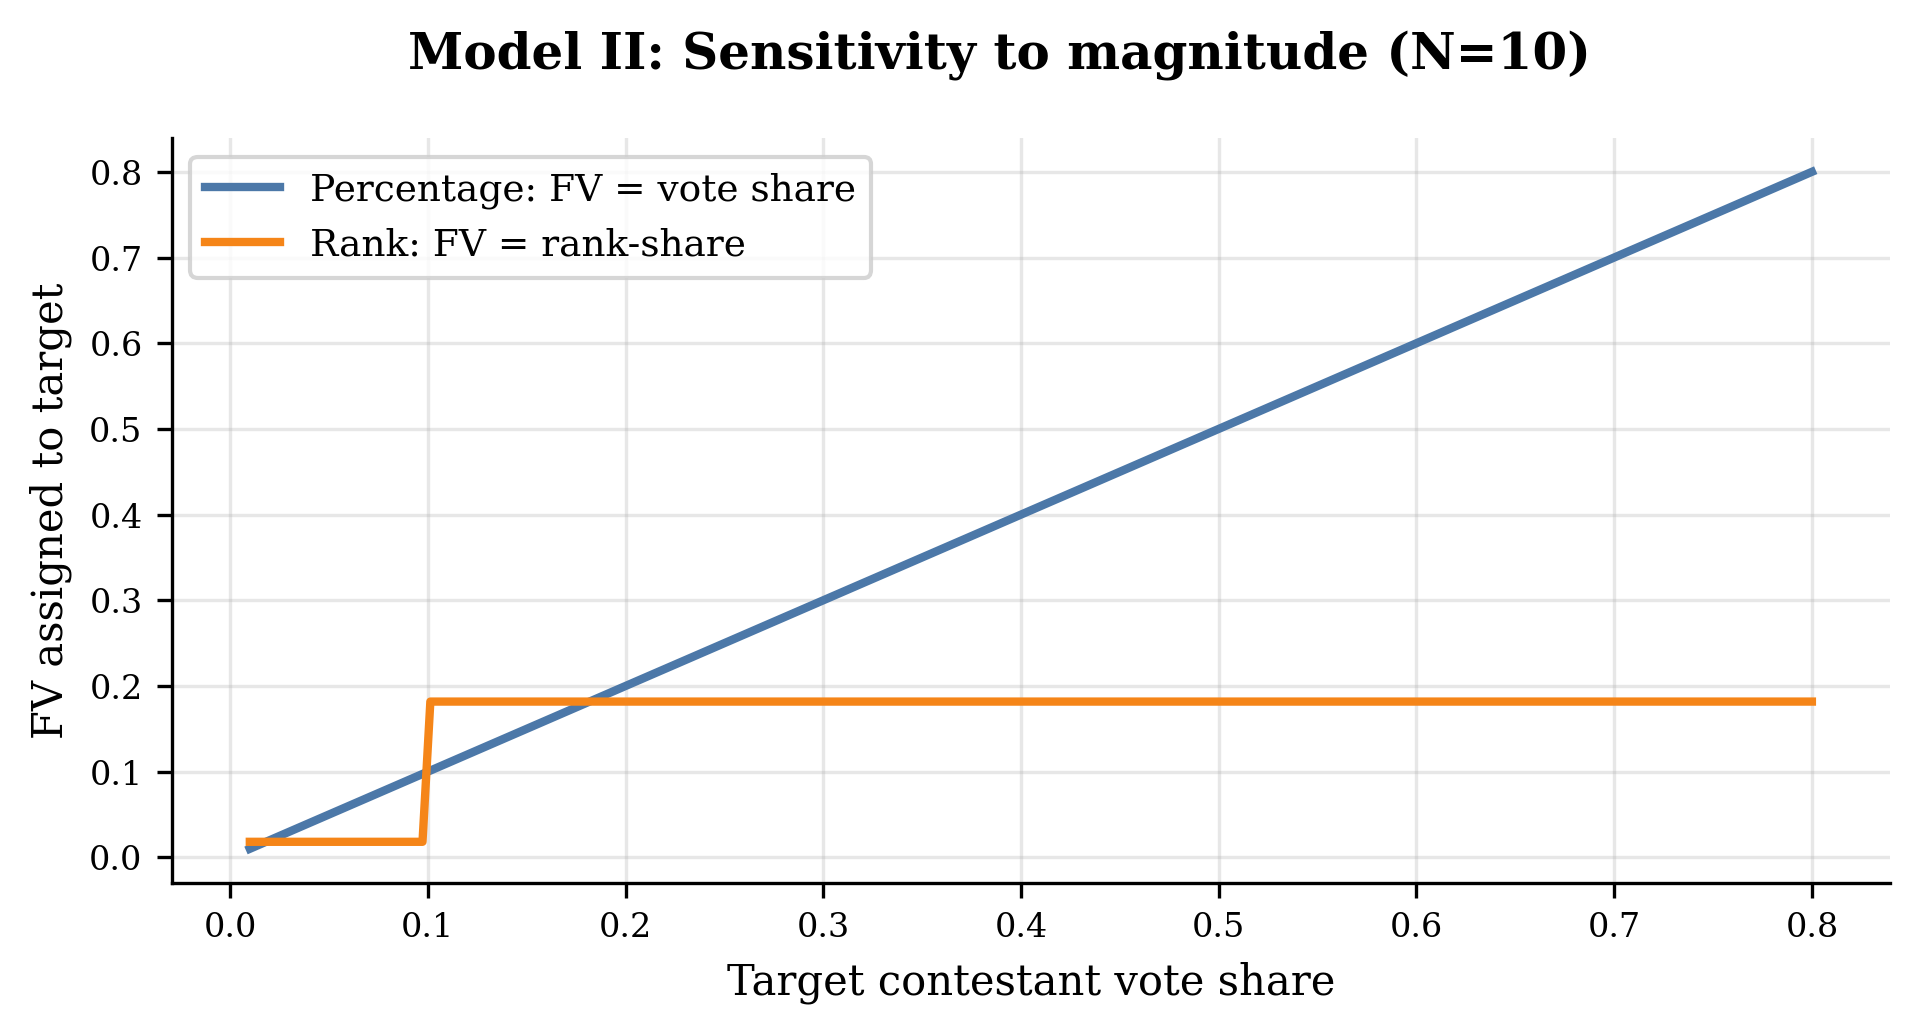

Saved: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/task2-math_sensitivity_vote_share_N10.pdf
Saved: /home/winbeau/Tools/jupyter-plot/figures/26Feb2-mcm/task2-math_sensitivity_vote_share_N10.pdf


In [4]:
plot_sensitivity_curve(N=N, output_path=OUT_PDF)
print("Saved:", OUT_PDF)
